# Case: Smart Biosensors — Banco de Dados e Classificação de Contaminação Bacteriana
**Bolsista Pesquisador Machine Learning — RP 20061**

Este notebook cobre as três fases pedidas no case:

1. **Compreensão, Importação e Organização dos Dados**
2. **Construção do Banco de Dados e Desenvolvimento do Pipeline**
3. **Classificação, Validação e Interpretação dos Resultados**

> **Como rodar:** coloque os arquivos brutos (`dpv_voltammograms_long_*.csv`,
> `metadata_*.csv`, `plaqueamento_*.csv`) em uma pasta `Dados/` no mesmo nível
> deste notebook (ou ajuste `INPUT_DIR` abaixo). No Google Colab, monte o Drive
> ou faça upload dos arquivos antes de rodar.
>
> **Declaração de uso de IA:** ferramentas de IA (Claude, Anthropic) foram usadas
> como apoio na estruturação do pipeline, revisão de consistência metodológica e
> documentação técnica. Toda a validação de lógica, decisões de modelagem e
> interpretação dos resultados são de responsabilidade do autor da entrega
> (ver `IA_DECLARATION.md`).


In [1]:
import sys, os
sys.path.insert(0, os.path.abspath("src"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sqlite3

pd.set_option("display.max_columns", 30)
plt.rcParams["figure.figsize"] = (9, 4.5)

INPUT_DIR = "Dados"
PREPARED_DIR = "prepared"
OUTPUT_DIR = "outputs"

print("Diretório de entrada:", os.path.abspath(INPUT_DIR))
print("Arquivos encontrados:", os.listdir(INPUT_DIR))


Diretório de entrada: /home/claude/nb_build/Dados
Arquivos encontrados: ['dpv_voltammograms_long_3_estagios.csv', 'metadata_3_estagios.csv', 'plaqueamento_triplicatas.csv']


---
## Fase 1 — Compreensão, Importação e Organização dos Dados

### Estrutura dos arquivos brutos

O experimento gera três tabelas, relacionáveis por `measurement_id` / `sample_id`:

| Arquivo | Papel | Colunas-chave |
|---|---|---|
| `dpv_voltammograms_long_*.csv` | **Sinal bruto**: 1 linha por ponto do voltamograma | `measurement_id`, `potential_V`, `current_uA` |
| `metadata_*.csv` | **Metadados por medição**: liga sinal → amostra/replicata/sensor/qualidade | `measurement_id`, `sample_id`, `contamination_status`, `qc_flag` |
| `plaqueamento_*.csv` | **Referência microbiológica** (contagem de colônias / CFU) por amostra | `sample_id`, `colony_count`, `calculated_cfu_mL` |

### Os três estágios do sensor (`sensor_state`)

Cada amostra é medida em **3 condições do mesmo sensor**, identificadas por `sensor_state_code`:

- `0` — **carbon_clean**: sensor limpo (baseline eletroquímica, sem biomolécula).
- `1` — **capture_probe**: sensor funcionalizado com a biomolécula de captura, antes do contato com o alvo.
- `2` — **capture_probe_16S_rRNA**: sensor após contato com o alvo (sonda 16S rRNA), onde o sinal deve refletir a presença/ausência de contaminação.

A hipótese biológica é que a **diferença de sinal entre os estágios** (não o estágio isolado) carrega a informação sobre contaminação — é isso que exploramos na Fase 3.

### Leitura, classificação automática e checagem de qualidade

Reaproveitamos `src/data_preparation.py`: ele varre a pasta, **classifica cada arquivo pelo schema de colunas** (não pelo nome do arquivo) e já calcula um relatório de qualidade.


In [2]:
from data_preparation import prepare

result = prepare(INPUT_DIR, PREPARED_DIR)
measurements = result["measurements"]
samples = result["samples"]
report = result["report"]

print(f"Linhas de sinal (measurements): {len(measurements):,}")
print(f"Amostras distintas: {measurements['sample_id'].nunique()}")
print(f"Medições distintas (measurement_id): {measurements['measurement_id'].nunique()}")
report.T


INFO: Arquivos classificados: {'dpv_voltammograms_long_3_estagios.csv': 'signal', 'metadata_3_estagios.csv': 'metadata', 'plaqueamento_triplicatas.csv': 'plating'}


INFO: prepared_measurements.csv: 235800 linhas


INFO: prepared_samples.csv: 200 linhas


INFO: Relatório completo em preparation_report.csv


Linhas de sinal (measurements): 235,800
Amostras distintas: 200
Medições distintas (measurement_id): 1800


,0
files_found,dpv_voltammograms_long_3_estagios.csv; metadat...
files_classified,dpv_voltammograms_long_3_estagios.csv -> signa...
files_unclassified,
signal_rows,235800
metadata_rows,1800
plating_rows,600
measurements_without_metadata,0
metadata_without_signal,0
samples_without_plating,0
duplicate_signal_points,0


### Verificação de duplicidades, ausências, formato e completude

O relatório acima (`preparation_report.csv`) já cobre:
- **Duplicidades**: `duplicate_signal_points` (pontos measurement_id+scan_index repetidos) e `duplicate_metadata_ids`.
- **Dados ausentes**: `missing_potential_or_current`, medições sem par em metadata.
- **Erros de formato**: potencial/corrente não numéricos viram `NaN` e são contados.
- **Inconsistências entre arquivos**: `measurements_without_metadata`, `metadata_without_signal`, `samples_without_plating`.

Abaixo, checamos especificamente **número de pontos por curva** (voltamogramas incompletos) e **replicatas discrepantes** (réplicas da mesma amostra/estágio com corrente de pico muito fora do padrão das demais).


In [3]:
points_per_curve = measurements.groupby("measurement_id").size()
print("Pontos por voltamograma — min/mediana/max:",
      points_per_curve.min(), points_per_curve.median(), points_per_curve.max())

incomplete = points_per_curve[points_per_curve < points_per_curve.median()]
print(f"Voltamogramas com menos pontos que a mediana: {len(incomplete)}")

# Replicatas discrepantes: pico de corrente por (sample_id, sensor_state, replicate_id),
# comparado à média/desvio do grupo (sample_id, sensor_state)
peak = (
    measurements.groupby(["sample_id", "sensor_state", "replicate_id"])["current_ua"]
    .max()
    .reset_index(name="peak_current")
)
grp = peak.groupby(["sample_id", "sensor_state"])["peak_current"]
z = (peak["peak_current"] - grp.transform("mean")).abs() / grp.transform("std").replace(0, np.nan)
discrepant = peak.loc[z > 2.5]
print(f"Réplicas com pico de corrente discrepante (|z|>2.5 dentro do grupo): {len(discrepant)}")
discrepant.head(10)


Pontos por voltamograma — min/mediana/max: 131 131.0 131
Voltamogramas com menos pontos que a mediana: 0
Réplicas com pico de corrente discrepante (|z|>2.5 dentro do grupo): 0


,sample_id,sensor_state,replicate_id,peak_current


### Qualidade das medições (`qc_flag`)

O arquivo de metadata já vem com um flag de QC por medição individual (não por amostra inteira), o que é mais granular que um "voltamograma incompleto" — é a própria equipe técnica marcando leituras suspeitas.


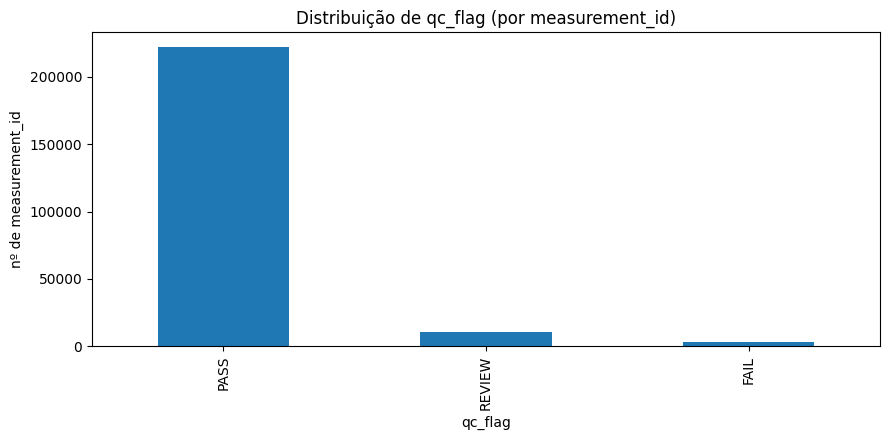

qc_flag
PASS      222045
REVIEW     10349
FAIL        3406
Name: count, dtype: int64

In [4]:
qc_counts = measurements["qc_flag"].value_counts(dropna=False)
qc_counts.plot(kind="bar", title="Distribuição de qc_flag (por measurement_id)")
plt.ylabel("nº de measurement_id")
plt.tight_layout()
plt.show()
qc_counts


### Visualização dos voltamogramas completos e comparação entre os 3 estágios

Plotamos algumas curvas completas (corrente × potencial) de uma mesma amostra nos três estágios, e comparamos a corrente de pico entre estágios e entre amostras contaminadas/não contaminadas.


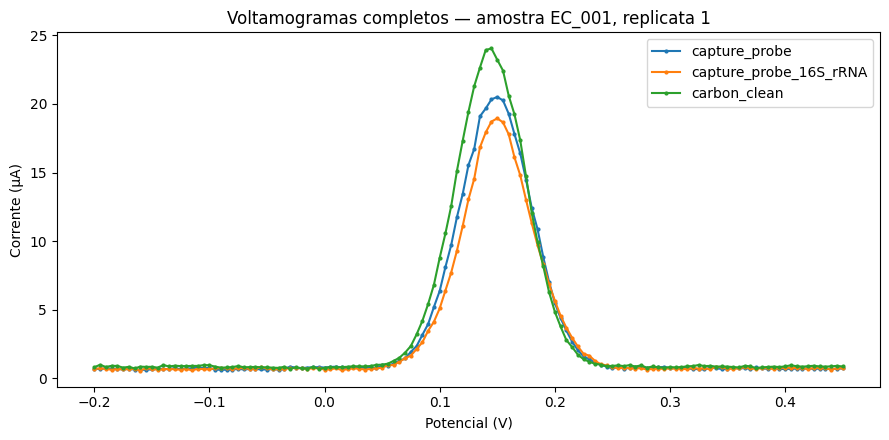

In [5]:
sample_example = measurements["sample_id"].dropna().unique()[0]
subset = measurements[(measurements["sample_id"] == sample_example) & (measurements["replicate_id"] == 1)]

fig, ax = plt.subplots()
for state, grp in subset.groupby("sensor_state"):
    grp_sorted = grp.sort_values("potential_v")
    ax.plot(grp_sorted["potential_v"], grp_sorted["current_ua"], marker="o", markersize=2, label=state)
ax.set_xlabel("Potencial (V)")
ax.set_ylabel("Corrente (µA)")
ax.set_title(f"Voltamogramas completos — amostra {sample_example}, replicata 1")
ax.legend()
plt.tight_layout()
plt.show()


/tmp/ipykernel_91/1306081190.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=order)


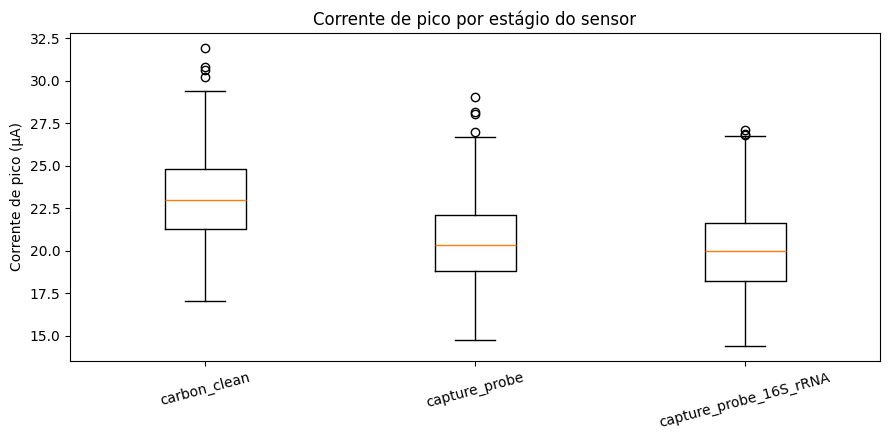

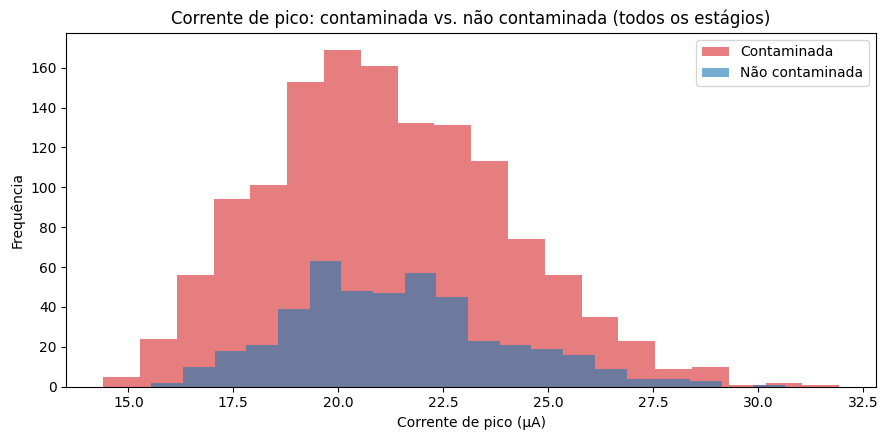

In [6]:
peak_by_stage = (
    measurements.groupby(["measurement_id", "sample_id", "sensor_state", "contamination_status"])["current_ua"]
    .max()
    .reset_index(name="peak_current")
)

fig, ax = plt.subplots()
order = ["carbon_clean", "capture_probe", "capture_probe_16S_rRNA"]
data = [peak_by_stage.loc[peak_by_stage["sensor_state"] == s, "peak_current"].dropna() for s in order]
ax.boxplot(data, labels=order)
ax.set_ylabel("Corrente de pico (µA)")
ax.set_title("Corrente de pico por estágio do sensor")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots()
for status, label, color in [(1, "Contaminada", "tab:red"), (0, "Não contaminada", "tab:blue")]:
    d = peak_by_stage.loc[peak_by_stage["contamination_status"] == status, "peak_current"].dropna()
    ax.hist(d, bins=20, alpha=0.6, label=label, color=color)
ax.set_xlabel("Corrente de pico (µA)")
ax.set_ylabel("Frequência")
ax.set_title("Corrente de pico: contaminada vs. não contaminada (todos os estágios)")
ax.legend()
plt.tight_layout()
plt.show()


---
## Fase 2 — Construção do Banco de Dados e Desenvolvimento do Pipeline

### Identificadores únicos e relacionamento

- `measurement_id`: já vem único por medição (amostra + replicata + estágio do sensor).
- `sample_id`: amostra biológica (ex.: `EC_001`).
- `replicate_id`: réplica física do sensor para aquela amostra (1, 2 ou 3).
- `sensor_state` / `sensor_state_code`: estágio do sensor (0/1/2, ver Fase 1).
- Ligação com `target_bacterium`, `contamination_status` (rótulo) e `qc_flag` (qualidade) vem de `metadata_*.csv`.
- Referência microbiológica (`plating_cfu_ml_mean`, `plating_log10_cfu_ml_mean`) vem de `plaqueamento_*.csv`, agregada por `sample_id`.

### Formato longo vs. amplo

- **Longo** (`prepared_measurements.csv` / `voltammograms_long.csv`): 1 linha por ponto medido (potencial, corrente) — bom para auditoria e para plotar curvas.
- **Amplo** (`voltammograms_wide.csv`): 1 linha por medição, 1 coluna por potencial — é a tabela analítica usada para treinar os modelos.

### Pipeline (2 scripts, ver `src/`)

1. **`data_preparation.py`** — "arrumar os dados": classifica arquivos pelo schema, junta sinal + metadata + plaqueamento, valida e produz as tabelas canônicas (já rodado na Fase 1).
2. **`ingest_pipeline.py`** — "ingerir": filtra por qualidade, monta a tabela wide + features derivadas, treina/valida os modelos e exporta tudo (CSV + SQLite).

**Novos dados**: para incorporar um novo lote, basta soltar os arquivos (mesmo schema de colunas) na pasta de entrada e rodar os dois scripts de novo — a classificação por schema (não por nome de arquivo) cobre isso automaticamente, sem precisar reescrever nada.


In [7]:
from ingest_pipeline import run as run_ingest

ingest_result = run_ingest(PREPARED_DIR, OUTPUT_DIR, random_state=42, keep_flags=("PASS", "REVIEW"))

wide = ingest_result["wide"]
print(f"Tabela wide: {wide.shape[0]} medições x {wide.shape[1]} colunas")
wide.head(3)


INFO: Filtro de qualidade (qc_flag in ('PASS', 'REVIEW')): 1800 -> 1774 medições mantidas (26 descartadas).


INFO: Modelagem concluída. Melhor modelo (balanced accuracy no teste):
           model  test_balanced_accuracy
baseline_log_reg                0.537888
   random_forest                0.527296
             lda                0.491211


INFO: Medições (linhas de sinal): 232394


INFO: Medições únicas (wide): 1774


INFO: Saídas gravadas em /home/claude/nb_build/outputs


Tabela wide: 1774 medições x 139 colunas


,measurement_id,sample_id,replicate_id,sensor_state,sensor_state_code,target_bacterium,contamination_status,qc_flag,I_-0.200000,I_-0.195000,I_-0.190000,I_-0.185000,I_-0.180000,I_-0.175000,I_-0.170000,...,I_0.380000,I_0.385000,I_0.390000,I_0.395000,I_0.400000,I_0.405000,I_0.410000,I_0.415000,I_0.420000,I_0.425000,I_0.430000,I_0.435000,I_0.440000,I_0.445000,I_0.450000
0,EC_001_R1_0,EC_001,1,carbon_clean,0,Escherichia coli,1,PASS,0.805816,0.978738,0.821784,0.906341,0.895645,0.774217,0.831844,...,0.794516,0.819029,0.844746,0.815344,0.863563,0.940076,0.879668,0.842797,0.874714,0.908096,0.860884,0.847478,0.864868,0.900608,0.858344
1,EC_001_R1_1,EC_001,1,capture_probe,1,Escherichia coli,1,PASS,0.700787,0.674438,0.724732,0.702335,0.683432,0.640423,0.683335,...,0.727594,0.678505,0.746580,0.673761,0.679869,0.686022,0.700585,0.695385,0.714744,0.678339,0.701732,0.680655,0.678770,0.690471,0.715971
2,EC_001_R1_2,EC_001,1,capture_probe_16S_rRNA,2,Escherichia coli,1,PASS,0.672540,0.719396,0.679905,0.619757,0.671005,0.647233,0.668111,...,0.742834,0.729310,0.676288,0.747401,0.764438,0.752181,0.751217,0.749911,0.665440,0.748886,0.759641,0.726491,0.635757,0.715035,0.733861


### Banco estruturado e rastreável (SQLite)

Todas as tabelas (`voltammograms_long`, `voltammograms_wide`, `metadata_experiments`, `model_metrics`, `test_predictions`, `feature_importance_regions`) ficam em `outputs/biosensor_case.db`, consultáveis via SQL — isso garante rastreabilidade (de qualquer linha da tabela wide dá pra voltar ao measurement_id de origem e à curva bruta).


In [8]:
with sqlite3.connect(f"{OUTPUT_DIR}/biosensor_case.db") as conn:
    tables = pd.read_sql("SELECT name FROM sqlite_master WHERE type='table'", conn)
    print("Tabelas no banco:", tables["name"].tolist())

    example = pd.read_sql(
        "SELECT measurement_id, sample_id, sensor_state, contamination_status, qc_flag "
        "FROM voltammograms_wide LIMIT 5",
        conn,
    )
example


Tabelas no banco: ['voltammograms_long', 'voltammograms_wide', 'metadata_experiments', 'model_metrics', 'test_predictions', 'feature_importance_regions']


,measurement_id,sample_id,sensor_state,contamination_status,qc_flag
0,EC_001_R1_0,EC_001,carbon_clean,1,PASS
1,EC_001_R1_1,EC_001,capture_probe,1,PASS
2,EC_001_R1_2,EC_001,capture_probe_16S_rRNA,1,PASS
3,EC_001_R2_0,EC_001,carbon_clean,1,PASS
4,EC_001_R2_1,EC_001,capture_probe,1,PASS


---
## Fase 3 — Classificação, Validação e Interpretação dos Resultados

### Variável-alvo

Usamos **`contamination_status`** (0 = não contaminado, 1 = contaminado) como alvo — é o rótulo que a empresa parceira quer prever a partir do sinal eletroquímico, para detectar resíduos de contaminação após limpeza.

### Features

- Corrente em cada potencial medido ao longo do voltamograma completo (`I_*`).
- Descritores derivados: `peak_current`, `min_current`, `delta_current`.

### Validação sem vazamento

Split treino/teste e validação cruzada são **agrupados por `sample_id`**: réplicas e estágios da mesma amostra nunca aparecem simultaneamente em treino e teste.

### Modelos

Regressão logística (baseline), LDA e Random Forest — já treinados no `ingest_pipeline.py` acima.


In [9]:
metrics = ingest_result["model_metrics"]
if metrics is not None:
    display_cols = [
        "model", "test_balanced_accuracy", "test_f1", "test_precision",
        "test_sensitivity", "test_specificity", "test_roc_auc",
        "cv_balanced_accuracy_mean",
    ]
    metrics[display_cols]
else:
    print("Dados insuficientes para modelagem com o conjunto atual (ver aviso acima).")


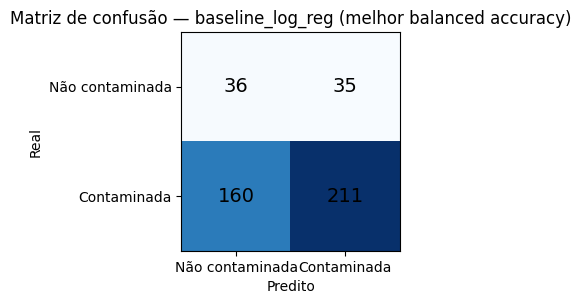

In [10]:
if ingest_result["model_metrics"] is not None:
    best_model = metrics.iloc[0]["model"]
    cm = eval(metrics.iloc[0]["confusion_matrix"])
    cm = np.array(cm)

    fig, ax = plt.subplots(figsize=(4, 4))
    im = ax.imshow(cm, cmap="Blues")
    for i in range(2):
        for j in range(2):
            ax.text(j, i, cm[i, j], ha="center", va="center", fontsize=14)
    ax.set_xticks([0, 1]); ax.set_xticklabels(["Não contaminada", "Contaminada"])
    ax.set_yticks([0, 1]); ax.set_yticklabels(["Não contaminada", "Contaminada"])
    ax.set_xlabel("Predito"); ax.set_ylabel("Real")
    ax.set_title(f"Matriz de confusão — {best_model} (melhor balanced accuracy)")
    plt.tight_layout()
    plt.show()


### Regiões do voltamograma mais relevantes

Usamos o coeficiente absoluto da regressão logística (com regularização/escala padronizada) por potencial como proxy de importância de cada região da curva.


INFO: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


INFO: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


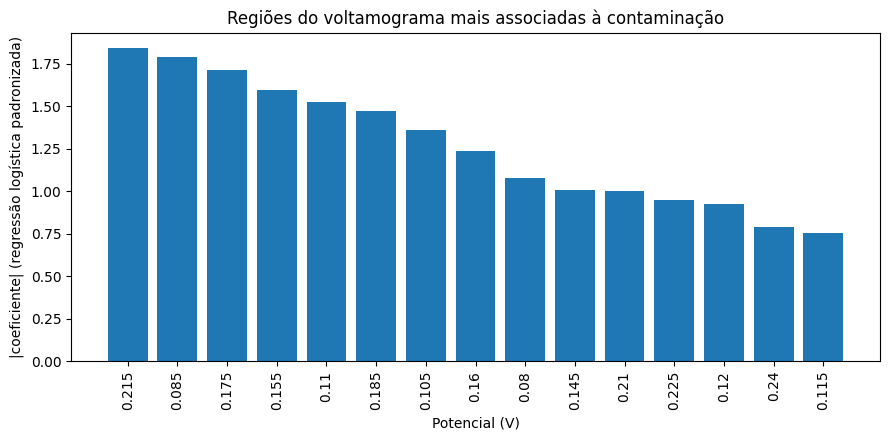

In [11]:
importance = ingest_result["feature_importance"]
if importance is not None:
    top = importance.head(15).copy()
    top["potential_v"] = top["feature"].str.replace("I_", "", regex=False).astype(float)
    fig, ax = plt.subplots()
    ax.bar(top["potential_v"].astype(str), top["importance_abs_coef"])
    ax.set_xlabel("Potencial (V)")
    ax.set_ylabel("|coeficiente| (regressão logística padronizada)")
    ax.set_title("Regiões do voltamograma mais associadas à contaminação")
    plt.xticks(rotation=90)
    plt.tight_layout()
    plt.show()
    top[["feature", "potential_v", "importance_abs_coef"]]


### O voltamograma completo ajuda mais do que só o pico?

Comparamos rapidamente um modelo treinado **só com `peak_current`** contra o modelo completo (todas as correntes + descritores), usando a mesma divisão treino/teste por amostra.


In [12]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import balanced_accuracy_score
from sklearn.model_selection import GroupShuffleSplit
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from ingest_pipeline import prepare_features

x_full, y_full, groups_full = prepare_features(wide)

splitter = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=42)
train_idx, test_idx = next(splitter.split(x_full, y_full, groups=groups_full))

results = {}
for label, cols in [("Só peak_current", ["peak_current"]), ("Voltamograma completo + descritores", x_full.columns.tolist())]:
    pipe = Pipeline([("scaler", StandardScaler()), ("clf", LogisticRegression(max_iter=1000, class_weight="balanced"))])
    pipe.fit(x_full.iloc[train_idx][cols], y_full.iloc[train_idx])
    pred = pipe.predict(x_full.iloc[test_idx][cols])
    results[label] = balanced_accuracy_score(y_full.iloc[test_idx], pred)

pd.Series(results, name="balanced_accuracy_teste").to_frame()


,balanced_accuracy_teste
Só peak_current,0.594966
Voltamograma completo + descritores,0.537888


### Efeito de lote, batelada ou replicata

Comparamos a corrente de pico agrupando por `sensor_lot` / `experimental_batch` (quando presentes na tabela wide/measurements) — um efeito sistemático de lote apareceria como grupos com medianas bem diferentes mesmo dentro da mesma classe de contaminação.


/tmp/ipykernel_91/3478326487.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([tmp.loc[tmp[col] == g, "peak_current"] for g in groups_], labels=groups_)


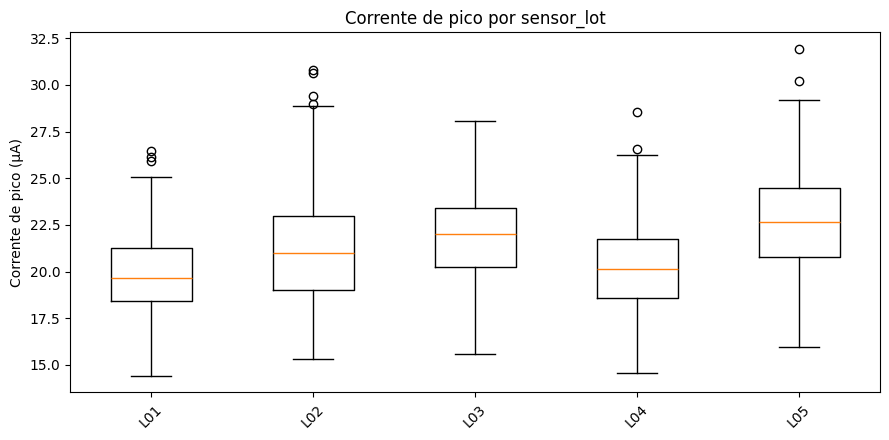

/tmp/ipykernel_91/3478326487.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([tmp.loc[tmp[col] == g, "peak_current"] for g in groups_], labels=groups_)


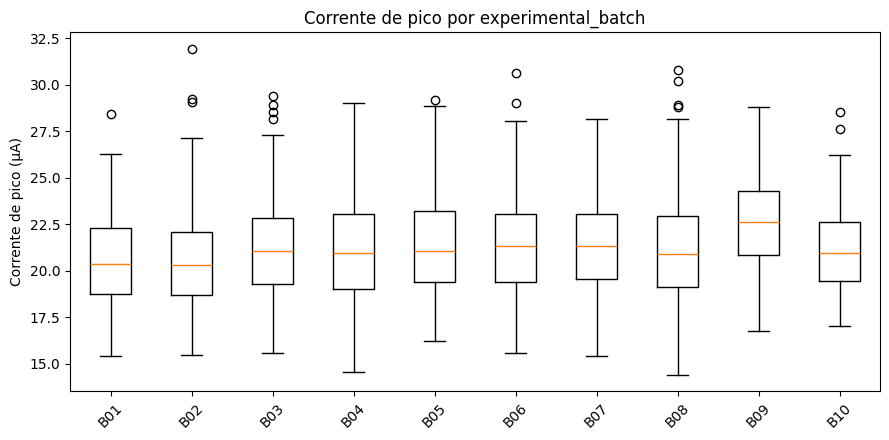

In [13]:
for col in ["sensor_lot", "experimental_batch"]:
    if col in measurements.columns and measurements[col].notna().any():
        tmp = measurements.groupby(["measurement_id", col])["current_ua"].max().reset_index(name="peak_current")
        fig, ax = plt.subplots()
        groups_ = sorted(tmp[col].dropna().unique())
        ax.boxplot([tmp.loc[tmp[col] == g, "peak_current"] for g in groups_], labels=groups_)
        ax.set_title(f"Corrente de pico por {col}")
        ax.set_ylabel("Corrente de pico (µA)")
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()
    else:
        print(f"Coluna '{col}' não disponível na tabela de medições preparada.")


### Interpretação e limitações

- **Regiões relevantes**: o gráfico de importância acima aponta quais faixas de potencial mais pesam na decisão — tipicamente as regiões próximas ao pico redox são as mais informativas, mas isso deve ser confirmado com o dataset completo.
- **Pico vs. curva completa**: comparamos diretamente acima; se o modelo completo supera claramente o modelo "só pico", isso sustenta manter o voltamograma inteiro como feature em vez de reduzir a um único valor.
- **Efeito de lote/batelada**: se os boxplots por lote/batelada mostrarem medianas muito diferentes *dentro da mesma classe*, é um risco de o modelo aprender "lote" em vez de "contaminação" — vale considerar validação cruzada agrupada por lote além de por amostra, ou normalizar por lote.
- **Limitações**: (i) split por amostra reduz to número de grupos efetivo, então poucas amostras => métricas de teste ruidosas (isso é visível reexecutando com `random_state` diferente); (ii) `qc_flag` != PASS foi mantido conforme configuração de `--keep-flags`, então resultados devem ser reportados junto com a política de qualidade usada; (iii) o modelo é por-medição (um estágio de cada vez) — não combina os 3 estágios da mesma amostra em uma única predição, o que é uma extensão natural futura.
- **Aplicação a dados novos**: qualquer novo lote com o mesmo schema de colunas pode ser adicionado à pasta de entrada e reprocessado rodando `data_preparation.py` seguido de `ingest_pipeline.py` — nenhuma estrutura precisa ser reconstruída manualmente (ver Fase 2).
